In [1]:
import torch
import numpy as np
import pandas as pd

import random
import os
import re

from scipy import stats


In [2]:
SEED = 1984

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED) 

In [3]:
fspen_df_1984 = pd.read_csv("fspen_metrics_1984.csv") 
fspen_df_1985 = pd.read_csv("fspen_metrics_1985.csv") 
fspen_df_1986 = pd.read_csv("fspen_metrics_1986.csv") 

In [4]:
fspen_df_1984

,nisqa,stoi,srmr,pesq,dnsmos,sisdr,rtf_full,rtf_chunk
0,"tensor([1.912, 2.727, 2.446, 2.723, 2.941])",tensor([-0.711]),tensor([8.245]),tensor([1.505]),"tensor([2.793, 2.374, 3.242, 2.074], dtype=tor...",tensor([-18.810]),tensor(0.081),tensor(0.101)


In [5]:
def get_values(df1, df2, df3, metric):
    values = [df[metric].values[0] for df in [df1, df2, df3]]
    values = np.array([list(map(float, re.findall(r"\d+\.\d+", x))) for x in values])
    return values

In [6]:
all_metrics = ["nisqa", "pesq", "stoi", "srmr", "dnsmos", "sisdr", "rtf_full", "rtf_chunk"]

In [7]:
def print_metric_results(df1, df2, df3):
    for metric in all_metrics:
        values = get_values(df1, df2, df3, metric)
        val_mean = values.mean(axis=0)
        se = stats.sem(values, axis=0)

        # print(val_mean, se)

        if metric == "nisqa":
            nisqa_names = ["mos", "noise", "disc", "col", "loud"]
            for i in range(len(val_mean)):
                # print(val_mean)
                ci_low, ci_high = stats.t.interval(0.95, df=len(values)-1, loc=val_mean[i], scale=se[i])
                # print(val_mean[i], ci_low)
                print(f"Metric: {metric}_{nisqa_names[i]}")
                print(f"mean = {val_mean[i]:.3f}")
                print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
                print(f"± = {(ci_high - val_mean[i]):.3f}")
        elif metric == "dnsmos":
            dnsmos_names = ["mos", "sig", "bak", "ovr"]
            for i in range(len(val_mean)):
                ci_low, ci_high = stats.t.interval(0.95, df=len(values)-1, loc=val_mean[i], scale=se[i])

                print(f"Metric: {metric}_{dnsmos_names[i]}")
                print(f"mean = {val_mean[i]:.3f}")
                print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
                print(f"± = {(ci_high - val_mean[i]):.3f}")
        else:
            # val_mean = values.mean()
            # se = stats.sem(values)
            # print(val_mean, se, len(values)-1, values)
            # break
            ci_low, ci_high = stats.t.interval(0.95, df=len(values)-1, loc=val_mean, scale=se)
            # print(ci_low, ci_high)
            print(f"Metric: {metric}")
            print(f"mean = {val_mean[0]:.3f}")
            print(f"95% CI = [{ci_low[0]:.3f}, {ci_high[0]:.3f}]")
            print(f"± = {(ci_high[0] - val_mean[0]):.3f}")

        print()
        print("===" * 20)
        print()

In [8]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 1.912
95% CI = [1.809, 2.015]
± = 0.103
Metric: nisqa_noise
mean = 2.666
95% CI = [2.528, 2.804]
± = 0.138
Metric: nisqa_disc
mean = 2.477
95% CI = [2.327, 2.627]
± = 0.150
Metric: nisqa_col
mean = 2.737
95% CI = [2.663, 2.811]
± = 0.074
Metric: nisqa_loud
mean = 2.921
95% CI = [2.847, 2.995]
± = 0.074


Metric: pesq
mean = 1.559
95% CI = [1.328, 1.790]
± = 0.231


Metric: stoi
mean = 0.726
95% CI = [0.649, 0.803]
± = 0.077


Metric: srmr
mean = 8.252
95% CI = [7.005, 9.499]
± = 1.247


Metric: dnsmos_mos
mean = 2.840
95% CI = [2.665, 3.015]
± = 0.175
Metric: dnsmos_sig
mean = 2.485
95% CI = [2.060, 2.910]
± = 0.425
Metric: dnsmos_bak
mean = 3.221
95% CI = [2.960, 3.482]
± = 0.261
Metric: dnsmos_ovr
mean = 2.155
95% CI = [1.788, 2.521]
± = 0.367


Metric: sisdr
mean = 17.893
95% CI = [10.836, 24.950]
± = 7.057


Metric: rtf_full
mean = 0.076
95% CI = [0.063, 0.088]
± = 0.013


Metric: rtf_chunk
mean = 0.094
95% CI = [0.080, 0.109]
± = 0.014




In [9]:
fspen_df_1984 = pd.read_csv("fspen_48khz_metrics_1984.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_metrics_1985.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_metrics_1986.csv") 

In [10]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.740
95% CI = [3.604, 3.875]
± = 0.135
Metric: nisqa_noise
mean = 3.993
95% CI = [3.877, 4.109]
± = 0.116
Metric: nisqa_disc
mean = 3.728
95% CI = [3.639, 3.818]
± = 0.089
Metric: nisqa_col
mean = 3.813
95% CI = [3.717, 3.909]
± = 0.096
Metric: nisqa_loud
mean = 3.904
95% CI = [3.831, 3.977]
± = 0.073


Metric: pesq
mean = 2.339
95% CI = [2.145, 2.533]
± = 0.194


Metric: stoi
mean = 0.883
95% CI = [0.861, 0.905]
± = 0.022


Metric: srmr
mean = 9.467
95% CI = [8.821, 10.113]
± = 0.646


Metric: dnsmos_mos
mean = 3.170
95% CI = [3.093, 3.247]
± = 0.077
Metric: dnsmos_sig
mean = 3.027
95% CI = [2.991, 3.063]
± = 0.036
Metric: dnsmos_bak
mean = 3.827
95% CI = [3.757, 3.897]
± = 0.070
Metric: dnsmos_ovr
mean = 2.713
95% CI = [2.657, 2.769]
± = 0.056


Metric: sisdr
mean = 12.370
95% CI = [10.053, 14.687]
± = 2.317


Metric: rtf_full
mean = 0.107
95% CI = [0.092, 0.122]
± = 0.015


Metric: rtf_chunk
mean = 0.155
95% CI = [0.136, 0.174]
± = 0.019




In [11]:
fspen_df_1984 = pd.read_csv("fspen_48khz_enc_ext_1984_metrics.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_enc_ext_1985_metrics.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_enc_ext_1986_metrics.csv") 

In [12]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.676
95% CI = [3.545, 3.807]
± = 0.131
Metric: nisqa_noise
mean = 3.876
95% CI = [3.845, 3.908]
± = 0.032
Metric: nisqa_disc
mean = 3.676
95% CI = [3.543, 3.810]
± = 0.133
Metric: nisqa_col
mean = 3.820
95% CI = [3.715, 3.926]
± = 0.105
Metric: nisqa_loud
mean = 3.911
95% CI = [3.867, 3.954]
± = 0.043


Metric: pesq
mean = 2.320
95% CI = [2.270, 2.370]
± = 0.050


Metric: stoi
mean = 0.798
95% CI = [0.793, 0.803]
± = 0.005


Metric: srmr
mean = 7.801
95% CI = [7.711, 7.891]
± = 0.090


Metric: dnsmos_mos
mean = 3.284
95% CI = [3.261, 3.307]
± = 0.023
Metric: dnsmos_sig
mean = 3.157
95% CI = [3.113, 3.201]
± = 0.044
Metric: dnsmos_bak
mean = 3.802
95% CI = [3.785, 3.819]
± = 0.017
Metric: dnsmos_ovr
mean = 2.814
95% CI = [2.786, 2.843]
± = 0.029


Metric: sisdr
mean = 12.747
95% CI = [12.688, 12.807]
± = 0.060


Metric: rtf_full
mean = 0.138
95% CI = [0.112, 0.164]
± = 0.026


Metric: rtf_chunk
mean = 0.193
95% CI = [0.152, 0.234]
± = 0.041




In [13]:
fspen_df_1984 = pd.read_csv("fspen_48khz_enc_ext_overlap_1984_metrics.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_enc_ext_overlap_1985_metrics.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_enc_ext_overlap_1986_metrics.csv") 

In [14]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.644
95% CI = [3.485, 3.803]
± = 0.159
Metric: nisqa_noise
mean = 3.884
95% CI = [3.797, 3.972]
± = 0.087
Metric: nisqa_disc
mean = 3.641
95% CI = [3.482, 3.800]
± = 0.159
Metric: nisqa_col
mean = 3.788
95% CI = [3.663, 3.913]
± = 0.125
Metric: nisqa_loud
mean = 3.903
95% CI = [3.834, 3.971]
± = 0.069


Metric: pesq
mean = 2.330
95% CI = [2.254, 2.407]
± = 0.076


Metric: stoi
mean = 0.801
95% CI = [0.791, 0.811]
± = 0.010


Metric: srmr
mean = 7.797
95% CI = [7.582, 8.012]
± = 0.215


Metric: dnsmos_mos
mean = 3.279
95% CI = [3.242, 3.316]
± = 0.037
Metric: dnsmos_sig
mean = 3.152
95% CI = [3.127, 3.178]
± = 0.025
Metric: dnsmos_bak
mean = 3.807
95% CI = [3.770, 3.844]
± = 0.037
Metric: dnsmos_ovr
mean = 2.811
95% CI = [2.775, 2.846]
± = 0.035


Metric: sisdr
mean = 12.666
95% CI = [12.599, 12.733]
± = 0.067


Metric: rtf_full
mean = 0.132
95% CI = [0.123, 0.141]
± = 0.009


Metric: rtf_chunk
mean = 0.187
95% CI = [0.185, 0.189]
± = 0.002




In [15]:
fspen_df_1984 = pd.read_csv("fspen_48khz_overlap_no_ext_metrics_1984.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_overlap_no_ext_metrics_1985.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_overlap_no_ext_metrics_1986.csv") 

In [16]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.732
95% CI = [3.598, 3.867]
± = 0.135
Metric: nisqa_noise
mean = 4.006
95% CI = [3.889, 4.122]
± = 0.116
Metric: nisqa_disc
mean = 3.712
95% CI = [3.615, 3.809]
± = 0.097
Metric: nisqa_col
mean = 3.803
95% CI = [3.703, 3.903]
± = 0.100
Metric: nisqa_loud
mean = 3.906
95% CI = [3.816, 3.995]
± = 0.090


Metric: pesq
mean = 2.348
95% CI = [2.066, 2.630]
± = 0.282


Metric: stoi
mean = 0.885
95% CI = [0.876, 0.895]
± = 0.009


Metric: srmr
mean = 9.593
95% CI = [9.144, 10.041]
± = 0.448


Metric: dnsmos_mos
mean = 3.169
95% CI = [3.120, 3.217]
± = 0.049
Metric: dnsmos_sig
mean = 3.044
95% CI = [3.003, 3.085]
± = 0.041
Metric: dnsmos_bak
mean = 3.826
95% CI = [3.742, 3.910]
± = 0.084
Metric: dnsmos_ovr
mean = 2.728
95% CI = [2.721, 2.735]
± = 0.007


Metric: sisdr
mean = 13.078
95% CI = [12.395, 13.762]
± = 0.683


Metric: rtf_full
mean = 0.113
95% CI = [0.104, 0.122]
± = 0.009


Metric: rtf_chunk
mean = 0.171
95% CI = [0.146, 0.196]
± = 0.025




In [17]:
fspen_df_1984 = pd.read_csv("fspen_48khz_1984_voicebank.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_1985_voicebank.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_1986_voicebank.csv") 

In [18]:
all_metrics = ["nisqa", "pesq", "stoi", "srmr", "dnsmos"]

In [19]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.835
95% CI = [3.642, 4.028]
± = 0.193
Metric: nisqa_noise
mean = 4.140
95% CI = [4.003, 4.277]
± = 0.137
Metric: nisqa_disc
mean = 3.885
95% CI = [3.713, 4.057]
± = 0.172
Metric: nisqa_col
mean = 3.846
95% CI = [3.707, 3.985]
± = 0.139
Metric: nisqa_loud
mean = 3.800
95% CI = [3.706, 3.894]
± = 0.094


Metric: pesq
mean = 2.579
95% CI = [2.124, 3.034]
± = 0.455


Metric: stoi
mean = 0.894
95% CI = [0.869, 0.919]
± = 0.025


Metric: srmr
mean = 10.642
95% CI = [10.292, 10.992]
± = 0.350


Metric: dnsmos_mos
mean = 3.258
95% CI = [3.179, 3.336]
± = 0.079
Metric: dnsmos_sig
mean = 3.271
95% CI = [3.215, 3.328]
± = 0.057
Metric: dnsmos_bak
mean = 3.927
95% CI = [3.852, 4.001]
± = 0.075
Metric: dnsmos_ovr
mean = 2.957
95% CI = [2.879, 3.035]
± = 0.078




In [20]:
fspen_df_1984 = pd.read_csv("fspen_48khz_enc_ext_1984_voicebank.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_enc_ext_1985_voicebank.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_enc_ext_1986_voicebank.csv") 

In [21]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.895
95% CI = [3.847, 3.943]
± = 0.048
Metric: nisqa_noise
mean = 4.061
95% CI = [4.024, 4.099]
± = 0.037
Metric: nisqa_disc
mean = 3.893
95% CI = [3.857, 3.928]
± = 0.035
Metric: nisqa_col
mean = 3.929
95% CI = [3.879, 3.978]
± = 0.049
Metric: nisqa_loud
mean = 3.928
95% CI = [3.890, 3.966]
± = 0.038


Metric: pesq
mean = 2.649
95% CI = [2.586, 2.712]
± = 0.063


Metric: stoi
mean = 0.906
95% CI = [0.905, 0.907]
± = 0.001


Metric: srmr
mean = 8.865
95% CI = [8.808, 8.922]
± = 0.057


Metric: dnsmos_mos
mean = 3.367
95% CI = [3.348, 3.387]
± = 0.020
Metric: dnsmos_sig
mean = 3.390
95% CI = [3.364, 3.417]
± = 0.027
Metric: dnsmos_bak
mean = 3.910
95% CI = [3.889, 3.931]
± = 0.021
Metric: dnsmos_ovr
mean = 3.056
95% CI = [3.036, 3.076]
± = 0.020




In [22]:
fspen_df_1984 = pd.read_csv("fspen_48khz_overlap_ext_1984_voicebank.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_overlap_ext_1985_voicebank.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_overlap_ext_1986_voicebank.csv") 

In [23]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.887
95% CI = [3.776, 3.999]
± = 0.111
Metric: nisqa_noise
mean = 4.076
95% CI = [4.002, 4.151]
± = 0.074
Metric: nisqa_disc
mean = 3.890
95% CI = [3.792, 3.988]
± = 0.098
Metric: nisqa_col
mean = 3.917
95% CI = [3.806, 4.029]
± = 0.111
Metric: nisqa_loud
mean = 3.925
95% CI = [3.883, 3.968]
± = 0.042


Metric: pesq
mean = 2.679
95% CI = [2.631, 2.727]
± = 0.048


Metric: stoi
mean = 0.904
95% CI = [0.900, 0.909]
± = 0.004


Metric: srmr
mean = 8.863
95% CI = [8.748, 8.979]
± = 0.115


Metric: dnsmos_mos
mean = 3.374
95% CI = [3.342, 3.405]
± = 0.031
Metric: dnsmos_sig
mean = 3.387
95% CI = [3.372, 3.402]
± = 0.015
Metric: dnsmos_bak
mean = 3.909
95% CI = [3.874, 3.945]
± = 0.035
Metric: dnsmos_ovr
mean = 3.051
95% CI = [3.030, 3.072]
± = 0.021




In [24]:
fspen_df_1984 = pd.read_csv("fspen_48khz_overlap_no_ext_1984_voicebank.csv") 
fspen_df_1985 = pd.read_csv("fspen_48khz_overlap_no_ext_1985_voicebank.csv") 
fspen_df_1986 = pd.read_csv("fspen_48khz_overlap_no_ext_1986_voicebank.csv") 

In [25]:
print_metric_results(fspen_df_1984, fspen_df_1985, fspen_df_1986)

Metric: nisqa_mos
mean = 3.843
95% CI = [3.731, 3.955]
± = 0.112
Metric: nisqa_noise
mean = 4.155
95% CI = [4.092, 4.218]
± = 0.063
Metric: nisqa_disc
mean = 3.890
95% CI = [3.791, 3.990]
± = 0.100
Metric: nisqa_col
mean = 3.843
95% CI = [3.738, 3.948]
± = 0.105
Metric: nisqa_loud
mean = 3.800
95% CI = [3.710, 3.891]
± = 0.091


Metric: pesq
mean = 2.636
95% CI = [2.332, 2.940]
± = 0.304


Metric: stoi
mean = 0.897
95% CI = [0.888, 0.905]
± = 0.008


Metric: srmr
mean = 10.835
95% CI = [10.564, 11.107]
± = 0.271


Metric: dnsmos_mos
mean = 3.259
95% CI = [3.210, 3.308]
± = 0.049
Metric: dnsmos_sig
mean = 3.282
95% CI = [3.230, 3.334]
± = 0.052
Metric: dnsmos_bak
mean = 3.940
95% CI = [3.897, 3.982]
± = 0.043
Metric: dnsmos_ovr
mean = 2.973
95% CI = [2.941, 3.004]
± = 0.031




In [38]:
import torchaudio

DATA_PATH = "data/DS_10283_2791/clean_trainset_56spk_wav"

files = os.listdir(DATA_PATH)

lens = []

for file_name in files:
    signal, sr = torchaudio.load(os.path.join(DATA_PATH, file_name))

    lens.append(signal.shape[-1] / sr)

In [39]:
print("Max len:", max(lens))
print("Min len:", min(lens))
print("Mean len:", sum(lens) / len(lens))

Max len: 16.246875
Min len: 1.1734375
Mean len: 2.969052036836385


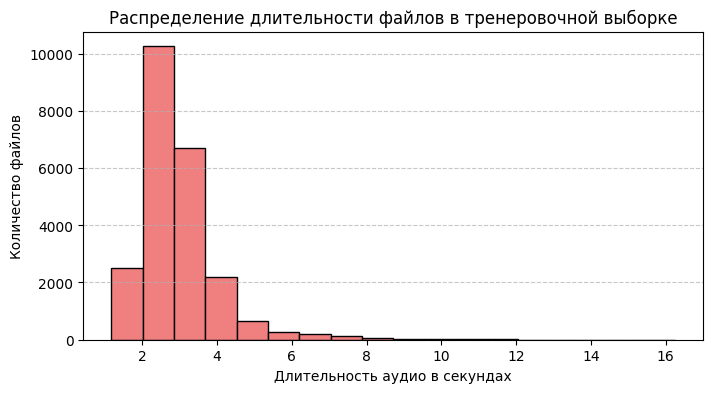

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(lens, bins=18, color='lightcoral', edgecolor='black')
plt.xlabel('Длительность аудио в секундах')
plt.ylabel('Количество файлов')
plt.title('Распределение длительности файлов в тренеровочной выборке')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [41]:
import torchaudio

DATA_PATH = "data/DS_10283_2791/clean_testset_wav"

files = os.listdir(DATA_PATH)

lens = []

for file_name in files:
    signal, sr = torchaudio.load(os.path.join(DATA_PATH, file_name))

    lens.append(signal.shape[-1] / sr)

In [42]:
print("Max len:", max(lens))
print("Min len:", min(lens))
print("Mean len:", sum(lens) / len(lens))

Max len: 9.768854166666667
Min len: 1.2375625
Mean len: 2.514600070792883


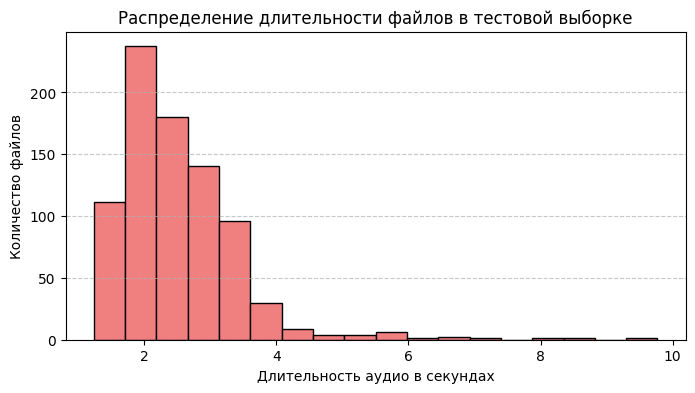

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(lens, bins=18, color='lightcoral', edgecolor='black')
plt.xlabel('Длительность аудио в секундах')
plt.ylabel('Количество файлов')
plt.title('Распределение длительности файлов в тестовой выборке')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()